In [165]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re
import numpy as np
import seaborn as sns
from pathlib import Path
from functools import lru_cache


# Folder containing your CSV files
folder = "/path/to/directory"

In [166]:
# Find all CSV files in the folder
csv_files = glob.glob(os.path.join(folder, "*.csv"))


dfs = {}  # dictionary to hold dataframes


for fpath in csv_files:
    # Use filename without extension as the dataframe name
    name = os.path.splitext(os.path.basename(fpath))[0]
    
    # Read CSV; adjust parameters if needed
    df = pd.read_csv(fpath)
    
    # Ensure the index column is numeric and usable as x-axis
    # If "Index" is a column, set it as index or keep as column
    if "Index" in df.columns:
        df["Index"] = pd.to_numeric(df["Index"], errors="coerce")
    
    dfs[name] = df


# Optionally, expose them as variables in the notebook's global namespace
globals().update(dfs)


dfs.keys()  # show the loaded dataframe names

dict_keys(['Tilt_Good', 'No_Tilt_Bad', 'No_Tilt_Good'])

In [167]:
df_all = pd.concat(
    [df.copy().assign(dataset=name) for name, df in dfs.items()],
    ignore_index=True
)

In [168]:
df_all

,Index,Avg Inten.,DF Avg,Astig,CTF Fit,DF Range,Tilt Angle,Rel Ice Thick.,Motion dist.,Motion curv.,UID,File,dataset
0,0,8.57,15949.768,141.38,3.855,1631,25.7,1.110,22.49,15.55,7906803624609673698,HW_123_tilt30_242-11_001_Dec24_22.00.22_X+0Y+0-1_patch_aligned_doseweighted.mrc,Tilt_Good
1,1,10.40,15941.739,158.65,4.036,1484,26.3,1.106,19.46,13.02,13062119298069133814,HW_123_tilt30_242-11_002_Dec24_22.00.29_X+0Y+0-2_patch_aligned_doseweighted.mrc,Tilt_Good
2,2,7.79,16514.842,104.70,3.830,1815,26.8,1.106,24.90,15.94,14719487537563117711,HW_123_tilt30_242-11_003_Dec24_22.00.36_X+0Y+0-3_patch_aligned_doseweighted.mrc,Tilt_Good
3,3,8.52,16876.404,117.72,4.053,1396,25.0,1.109,24.66,15.15,16022704154875515451,HW_123_tilt30_242-11_004_Dec24_22.00.43_X+0Y+0-4_patch_aligned_doseweighted.mrc,Tilt_Good
4,4,8.80,16596.109,35.02,3.702,1418,24.6,1.110,22.63,12.67,13903133662324163445,HW_123_tilt30_242-11_005_Dec24_22.00.50_X+0Y+0-5_patch_aligned_doseweighted.mrc,Tilt_Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78079,26023,9.71,9322.393,129.45,4.959,286,4.1,1.141,4.59,4.80,9854229409440196752,HW_123_497-132_021_Dec28_23.05.11_X-1Y-1-1_patch_aligned_doseweighted.mrc,No_Tilt_Good
78080,26024,7.85,22871.205,77.61,5.058,400,4.1,1.135,5.50,5.23,13888897207543191899,HW_123_499-110_013_Dec29_02.25.12_X+1Y+1-3_patch_aligned_doseweighted.mrc,No_Tilt_Good
78081,26025,8.41,8835.602,113.11,4.800,577,9.4,1.136,10.75,4.06,5462443861459685163,HW_123_499-24_019_Dec29_01.49.23_X+0Y+1-4_patch_aligned_doseweighted.mrc,No_Tilt_Good
78082,26026,8.42,16754.408,101.68,4.152,387,5.2,1.121,5.11,4.85,6281836091630895303,HW_123_499-49_045_Dec29_02.10.50_X+1Y-1-5_patch_aligned_doseweighted.mrc,No_Tilt_Good


In [169]:
mdoc_base_dirs = [
    Path("/path/to/first/mdoc/set"),
    Path("/path/to/second/mdoc/set"),
    Path("/path/to/third/mdoc/set"),
    Path("/path/to/fourth/mdoc/set")
]

# Build an index: mdoc filename (basename) -> full path
mdoc_index = {}
for base in mdoc_base_dirs:
    for p in base.rglob("*.mdoc"):
        # if duplicates exist, first one wins; change as needed
        mdoc_index.setdefault(p.name, p)

def file_to_mdoc_basename(file_value: str) -> str:
    """Convert the df 'File' value to the expected .mdoc basename: <something>.eer.mdoc"""
    s = Path(str(file_value)).name
    if "_patch_aligned_doseweighted.mrc" in s:
        s = s[: s.find("_patch_aligned_doseweighted.mrc")]  # keep through ".mrc"        
        return s + ".eer.mdoc"
    if s.endswith(".mdoc"):
        return s
    if s.endswith(".eer"):
        return s + ".mdoc"
    if ".eer" in s:
        s = s[: s.find(".eer") + 4]  # keep through ".eer"
        return s + ".mdoc"
    return s # fallback

df_all["mdoc_basename"] = df_all["File"].astype(str).map(file_to_mdoc_basename)
df_all["mdoc_path"] = df_all["mdoc_basename"].map(lambda n: mdoc_index.get(n, pd.NA))

@lru_cache(maxsize=None)
def parse_mdoc(path_str: str) -> dict:
    """
    Parse selected keys from the [FrameSet = 0] section of a SerialEM .mdoc file.
    Returns a dict with:
      TiltAngle, StagePositionX, StagePositionY, Defocus, ImageShiftX, ImageShiftY,
      RotationAngle, FlashCounter, FEGCurrent
    """
    out = {
        "TiltAngle": np.nan,
        "StagePositionX": np.nan, "StagePositionY": np.nan,
        "Defocus": np.nan,
        "ImageShiftX": np.nan, "ImageShiftY": np.nan,
        "RotationAngle": np.nan,
        "FlashCounter": np.nan,
        "FEGCurrent": np.nan,
    }

    p = Path(path_str)
    if not p.exists():
        return out

    wanted = {
        "TiltAngle", "StagePosition", "Defocus", "ImageShift",
        "RotationAngle", "FlashCounter", "FEGCurrent"
    }

    in_frameset0 = False
    with p.open("r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            if line.startswith("[FrameSet"):
                # accept "[FrameSet = 0]" and minor spacing variants
                in_frameset0 = ("0" in line and "=" in line and line.replace(" ", "").startswith("[FrameSet=0]"))
                continue

            if not in_frameset0 or "=" not in line:
                continue

            key, val = [x.strip() for x in line.split("=", 1)]
            if key not in wanted:
                continue

            if key in ("TiltAngle", "Defocus", "RotationAngle", "FEGCurrent"):
                out[key] = pd.to_numeric(val, errors="coerce")

            elif key == "FlashCounter":
                out[key] = pd.to_numeric(val, errors="coerce")

            elif key == "StagePosition":
                parts = val.split()
                if len(parts) >= 2:
                    out["StagePositionX"] = pd.to_numeric(parts[0], errors="coerce")
                    out["StagePositionY"] = pd.to_numeric(parts[1], errors="coerce")

            elif key == "ImageShift":
                parts = val.split()
                if len(parts) >= 2:
                    out["ImageShiftX"] = pd.to_numeric(parts[0], errors="coerce")
                    out["ImageShiftY"] = pd.to_numeric(parts[1], errors="coerce")

            # early exit if everything is filled (optional)
            # if all(pd.notna(v) for v in out.values()):
            #     break

    return out

meta = df_all["mdoc_path"].dropna().astype(str).map(parse_mdoc)
meta_df = pd.json_normalize(meta).reindex(df_all.index)  # align back to df_all rows

df_all = pd.concat([df_all, meta_df], axis=1)

df_all.tail()

,Index,Avg Inten.,DF Avg,Astig,CTF Fit,DF Range,Tilt Angle,Rel Ice Thick.,Motion dist.,Motion curv.,...,mdoc_path,TiltAngle,StagePositionX,StagePositionY,Defocus,ImageShiftX,ImageShiftY,RotationAngle,FlashCounter,FEGCurrent
78079,26023,9.71,9322.393,129.45,4.959,286,4.1,1.141,4.59,4.80,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_untilted_20251222/HW_123_497-132_021_Dec28_23.05.11_X-1Y-1-1.eer.mdoc,0.005093,-218.139,310.493,-3.01128,1.43536,-3.162900,174.7,349,6.15
78080,26024,7.85,22871.205,77.61,5.058,400,4.1,1.135,5.50,5.23,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_untilted_20251222/HW_123_499-110_013_Dec29_02.25.12_X+1Y+1-3.eer.mdoc,0.005093,-270.055,188.073,-3.00760,-1.28375,2.983010,174.7,349,5.61
78081,26025,8.41,8835.602,113.11,4.800,577,9.4,1.136,10.75,4.06,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_untilted_20251222/HW_123_499-24_019_Dec29_01.49.23_X+0Y+1-4.eer.mdoc,0.005093,-293.682,176.262,-3.15618,-2.57422,1.208600,174.7,349,6.15
78082,26026,8.42,16754.408,101.68,4.152,387,5.2,1.121,5.11,4.85,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_untilted_20251222/HW_123_499-49_045_Dec29_02.10.50_X+1Y-1-5.eer.mdoc,0.005093,-276.338,192.611,-2.65549,3.29913,1.449910,174.7,349,5.71
78083,26027,8.79,16611.730,29.39,4.303,250,1.4,1.140,5.42,5.23,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_untilted_20251222/HW_123_499-52_031_Dec29_02.04.03_X+0Y-1-1.eer.mdoc,0.005093,-280.702,186.109,-2.24368,2.55718,-0.975345,174.7,349,5.71


In [170]:
df_all.head()

,Index,Avg Inten.,DF Avg,Astig,CTF Fit,DF Range,Tilt Angle,Rel Ice Thick.,Motion dist.,Motion curv.,...,mdoc_path,TiltAngle,StagePositionX,StagePositionY,Defocus,ImageShiftX,ImageShiftY,RotationAngle,FlashCounter,FEGCurrent
0,0,8.57,15949.768,141.38,3.855,1631,25.7,1.110,22.49,15.55,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_001_Dec24_22.00.22_X+0Y+0-1.eer.mdoc,29.9679,-251.033,453.521,-1.64737,-0.337536,-0.171574,174.7,336,5.51
1,1,10.40,15941.739,158.65,4.036,1484,26.3,1.106,19.46,13.02,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_002_Dec24_22.00.29_X+0Y+0-2.eer.mdoc,29.9679,-251.034,453.521,-1.86398,-0.271113,0.267517,174.7,336,5.51
2,2,7.79,16514.842,104.70,3.830,1815,26.8,1.106,24.90,15.94,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_003_Dec24_22.00.36_X+0Y+0-3.eer.mdoc,29.9679,-251.032,453.521,-1.78124,0.169979,0.336909,174.7,336,5.51
3,3,8.52,16876.404,117.72,4.053,1396,25.0,1.109,24.66,15.15,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_004_Dec24_22.00.43_X+0Y+0-4.eer.mdoc,29.9679,-251.032,453.521,-1.51349,0.376166,-0.059296,174.7,336,5.51
4,4,8.80,16596.109,35.02,3.702,1418,24.6,1.110,22.63,12.67,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_005_Dec24_22.00.50_X+0Y+0-5.eer.mdoc,29.9679,-251.033,453.521,-1.43076,0.062504,-0.373555,174.7,336,5.51


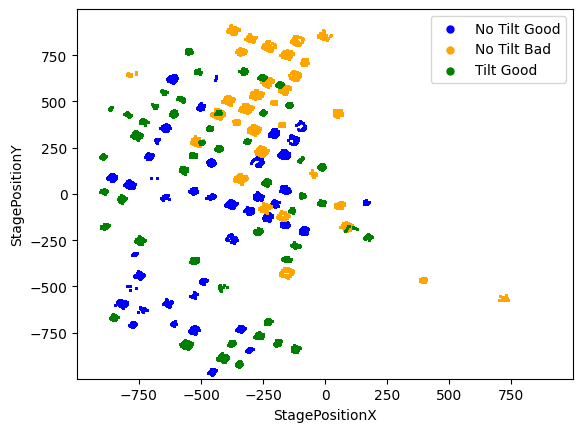

In [171]:
df_stats = df_all
x_axis = 'StagePositionX'
y_axis = 'StagePositionY'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', color='blue', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', color='orange', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', color='green', s=1)

plt.legend(markerscale=5)
plt.xlabel('StagePositionX')
plt.ylabel('StagePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)
plt.savefig(f"{folder}/Square_locations.png")
plt.show()

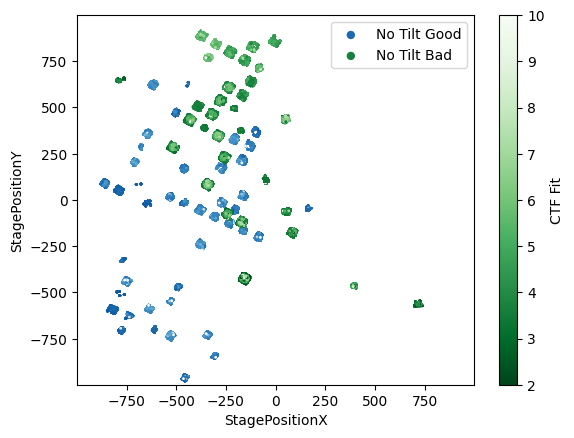

In [172]:
x_axis = 'StagePositionX'
y_axis = 'StagePositionY'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=1)
#plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=8, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar = plt.colorbar()
cbar.set_label("CTF Fit")
plt.xlabel('StagePositionX')
plt.ylabel('StagePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)
plt.savefig(f"{folder}/CTF_v_stage_position.png")
plt.show()

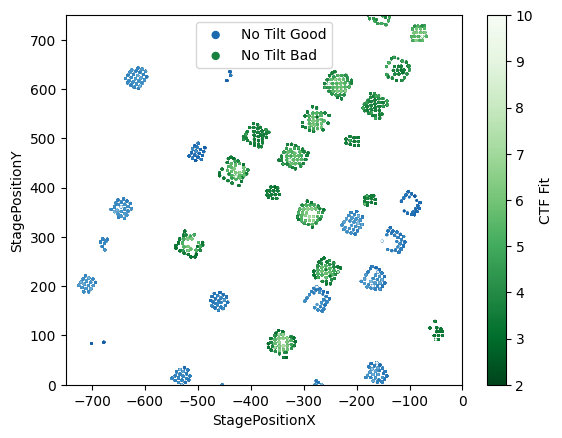

In [173]:
x_axis = 'StagePositionX'
y_axis = 'StagePositionY'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=1)
#plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=8, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar = plt.colorbar()
cbar.set_label("CTF Fit")
plt.xlabel('StagePositionX')
plt.ylabel('StagePositionY')
plt.grid(False)
plt.xlim(-750,0)
plt.ylim(0,750)
plt.savefig(f"{folder}/CTF_v_stage_position_zoom.png")
plt.show()

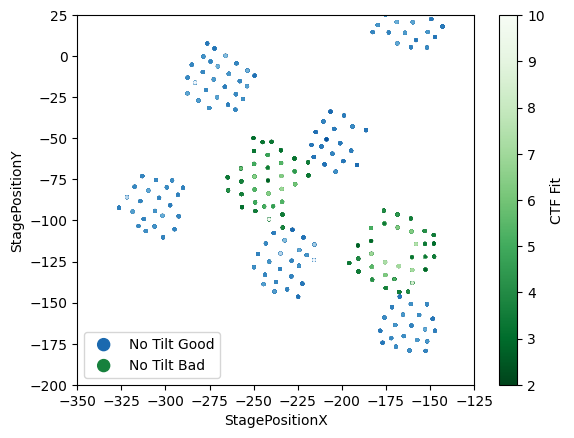

In [174]:
x_axis = 'StagePositionX'
y_axis = 'StagePositionY'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=3)
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=3)
#plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=8, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar = plt.colorbar()
cbar.set_label("CTF Fit")
plt.xlabel('StagePositionX')
plt.ylabel('StagePositionY')
plt.grid(False)
plt.xlim(-350,-125)
plt.ylim(-200,25)
plt.savefig(f"{folder}/CTF_v_stage_position_zoom2.png")
plt.show()

In [175]:
df_all.head()

,Index,Avg Inten.,DF Avg,Astig,CTF Fit,DF Range,Tilt Angle,Rel Ice Thick.,Motion dist.,Motion curv.,...,mdoc_path,TiltAngle,StagePositionX,StagePositionY,Defocus,ImageShiftX,ImageShiftY,RotationAngle,FlashCounter,FEGCurrent
0,0,8.57,15949.768,141.38,3.855,1631,25.7,1.110,22.49,15.55,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_001_Dec24_22.00.22_X+0Y+0-1.eer.mdoc,29.9679,-251.033,453.521,-1.64737,-0.337536,-0.171574,174.7,336,5.51
1,1,10.40,15941.739,158.65,4.036,1484,26.3,1.106,19.46,13.02,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_002_Dec24_22.00.29_X+0Y+0-2.eer.mdoc,29.9679,-251.034,453.521,-1.86398,-0.271113,0.267517,174.7,336,5.51
2,2,7.79,16514.842,104.70,3.830,1815,26.8,1.106,24.90,15.94,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_003_Dec24_22.00.36_X+0Y+0-3.eer.mdoc,29.9679,-251.032,453.521,-1.78124,0.169979,0.336909,174.7,336,5.51
3,3,8.52,16876.404,117.72,4.053,1396,25.0,1.109,24.66,15.15,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_004_Dec24_22.00.43_X+0Y+0-4.eer.mdoc,29.9679,-251.032,453.521,-1.51349,0.376166,-0.059296,174.7,336,5.51
4,4,8.80,16596.109,35.02,3.702,1418,24.6,1.110,22.63,12.67,...,/nfs/lcemdata/fischer/hms/20251222_HW_Janelia_Krios4_CDO1_CRL5-LRRC58/Grid1_tilt30_20251224/HW_123_tilt30_242-11_005_Dec24_22.00.50_X+0Y+0-5.eer.mdoc,29.9679,-251.033,453.521,-1.43076,0.062504,-0.373555,174.7,336,5.51


In [176]:
df_stats["TrueXPosition"] = df_stats["StagePositionX"] + df_stats["ImageShiftX"]
df_stats["TrueYPosition"] = df_stats["StagePositionY"] + df_stats["ImageShiftY"]

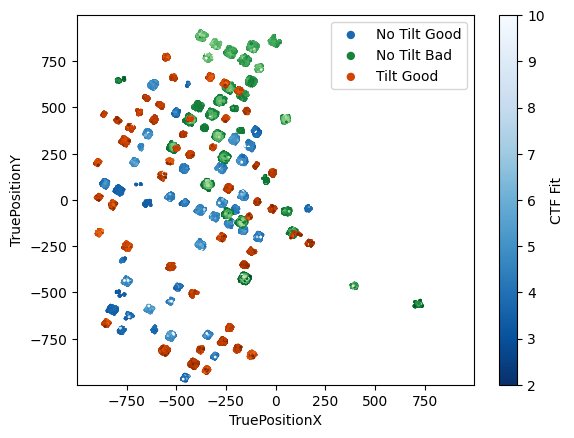

In [177]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=1)
cbar = plt.colorbar()
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=10, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar.set_label("CTF Fit")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)
plt.savefig(f"{folder}/CTF_v_true_position.png")
plt.show()

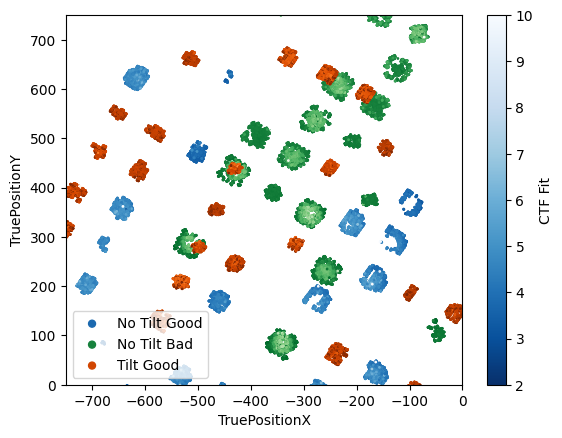

In [178]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=1)
cbar = plt.colorbar()
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=10, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar.set_label("CTF Fit")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-750,0)
plt.ylim(0,750)
plt.savefig(f"{folder}/CTF_v_true_position_zoom.png")
plt.show()

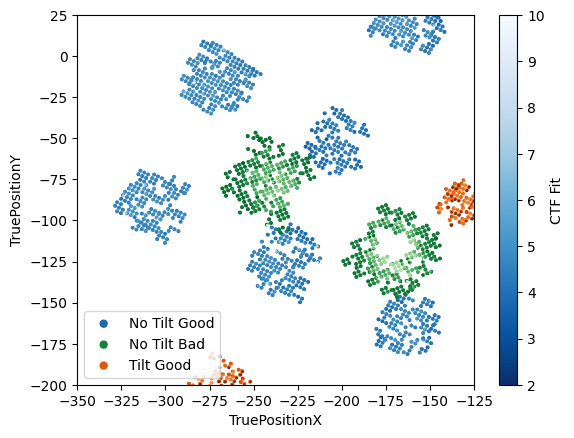

In [179]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=1)
cbar = plt.colorbar()
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=8, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar.set_label("CTF Fit")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-350,-125)
plt.ylim(-200,25)
plt.savefig(f"{folder}/CTF_v_true_position_zoom2.png")
plt.show()

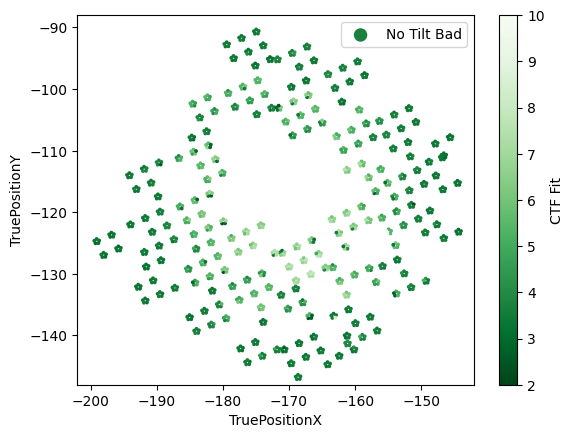

In [180]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

#plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=3)
#plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=8, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar = plt.colorbar()
cbar.set_label("CTF Fit")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-202,-142)
plt.ylim(-148,-88)
plt.savefig(f"{folder}/CTF_v_true_position_zoom3_bad.png")
plt.show()

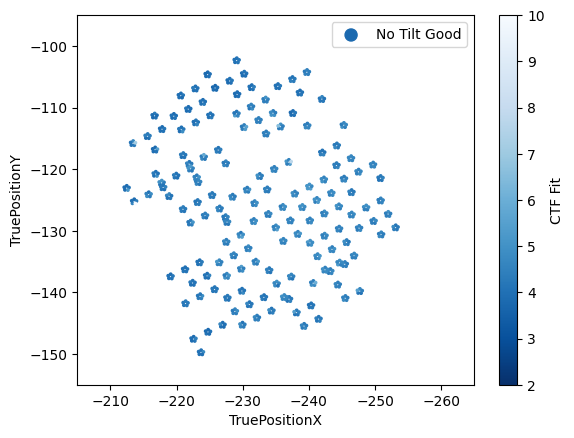

In [181]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=3)
#plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=1)
#plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=8, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar = plt.colorbar()
cbar.set_label("CTF Fit")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-205,-265)
plt.ylim(-155,-95)
plt.savefig(f"{folder}/CTF_v_true_position_zoom3_good.png")
plt.show()

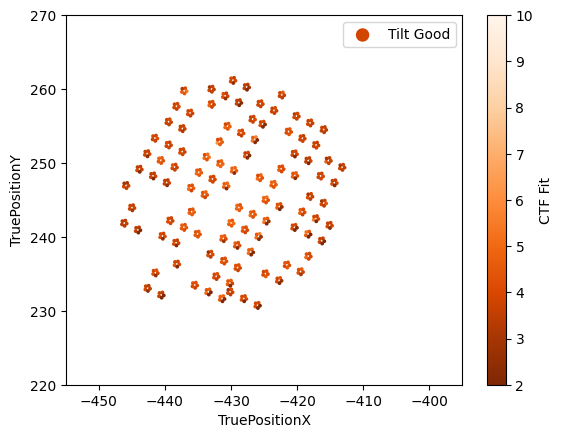

In [182]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

#plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["CTF Fit"], vmin=2, vmax=10, cmap='Blues_r', s=1)
#plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["CTF Fit"], vmin=2, vmax=10, cmap='Greens_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["CTF Fit"], vmin=2, vmax=10, cmap='Oranges_r', s=3)

plt.legend(markerscale=5)
cbar = plt.colorbar()
cbar.set_label("CTF Fit")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-455,-395)
plt.ylim(220,270)
plt.savefig(f"{folder}/CTF_v_true_position_zoom3_tilt.png")
plt.show()

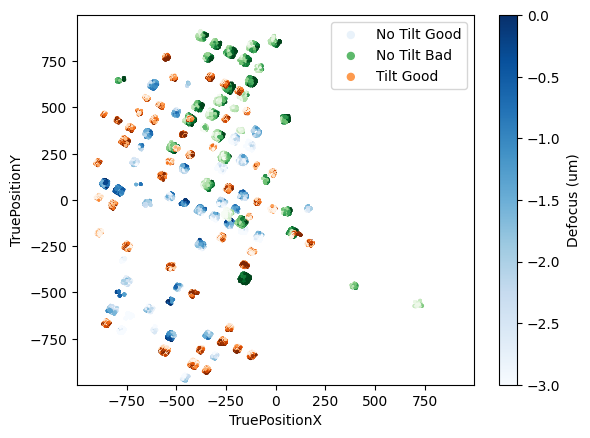

In [183]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["Defocus"], vmin=-3, vmax=0, cmap='Blues', s=1)
cbar = plt.colorbar()
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["Defocus"], vmin=-3, vmax=0, cmap='Greens', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["Defocus"], vmin=-3, vmax=0, cmap='Oranges', s=1)

plt.legend(markerscale=5)
cbar.set_label("Defocus (um)")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)
plt.savefig(f"{folder}/Defocus_v_true_position.png")
plt.show()

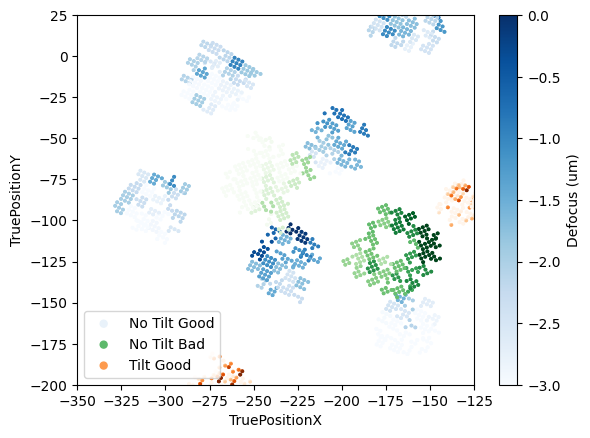

In [184]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["Defocus"], vmin=-3, vmax=0, cmap='Blues', s=1)
cbar = plt.colorbar()
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["Defocus"], vmin=-3, vmax=0, cmap='Greens', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["Defocus"], vmin=-3, vmax=0, cmap='Oranges', s=1)

plt.legend(markerscale=5)
cbar.set_label("Defocus (um)")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-350,-125)
plt.ylim(-200,25)
plt.savefig(f"{folder}/Defocus_v_true_position_zoom2.png")
plt.show()

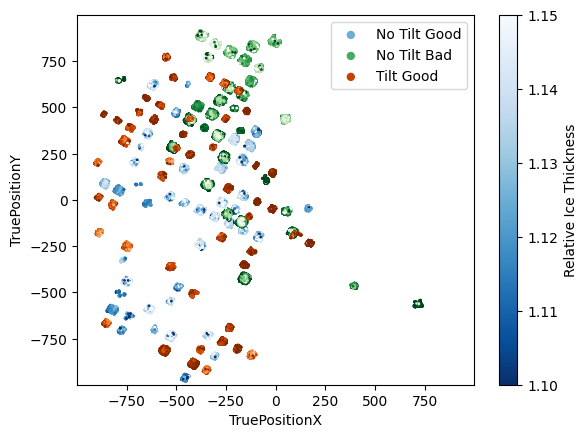

In [185]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Blues_r', s=1)
cbar = plt.colorbar()
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Greens_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar.set_label("Relative Ice Thickness")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)
plt.savefig(f"{folder}/IceThickness_v_true_position.png")
plt.show()

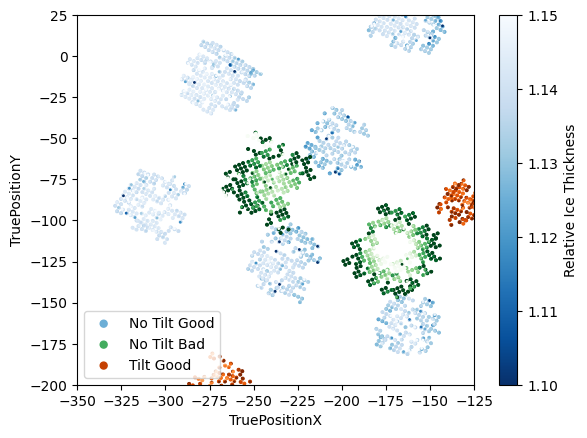

In [186]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Blues_r', s=1)
cbar = plt.colorbar()
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Greens_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar.set_label("Relative Ice Thickness")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-350,-125)
plt.ylim(-200,25)
plt.savefig(f"{folder}/IceThickness_v_true_position_zoom.png")
plt.show()

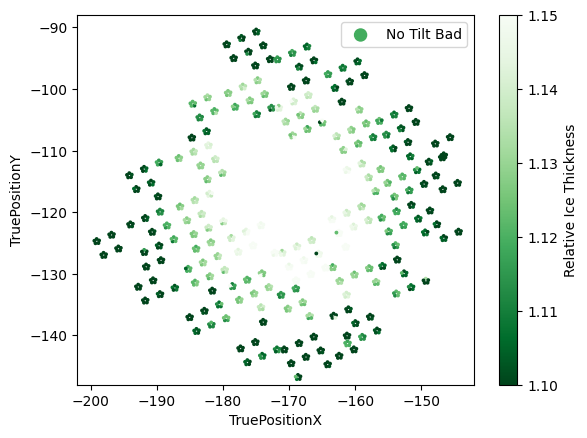

In [187]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

#plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Blues_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Greens_r', s=3)
cbar = plt.colorbar()
#plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar.set_label("Relative Ice Thickness")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-202,-142)
plt.ylim(-148,-88)
plt.savefig(f"{folder}/IceThickness_v_true_position_zoom3_bad.png")
plt.show()

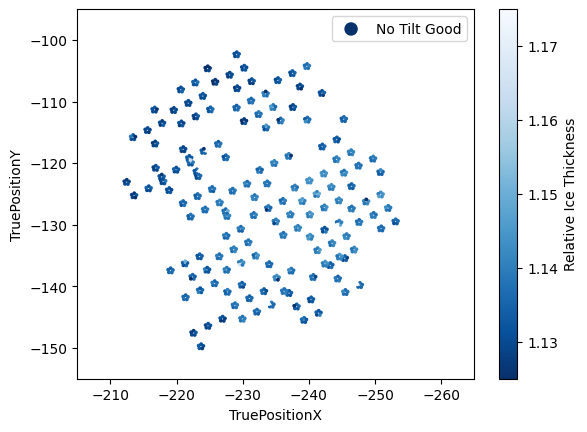

In [188]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["Rel Ice Thick."], vmin=1.125, vmax=1.175, cmap='Blues_r', s=3)
#plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Greens_r', s=1)
cbar = plt.colorbar()
#plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Oranges_r', s=1)

plt.legend(markerscale=5)
cbar.set_label("Relative Ice Thickness")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-205,-265)
plt.ylim(-155,-95)
plt.savefig(f"{folder}/IceThickness_v_true_position_zoom3_good.png")
plt.show()

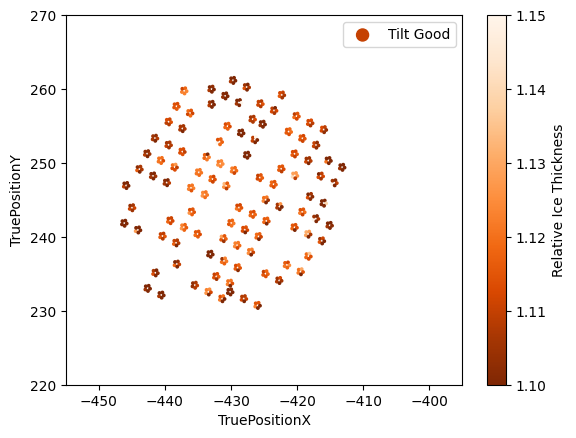

In [189]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'
dataset2 = 'No_Tilt_Bad'
dataset3 = 'Tilt_Good'

#plt.scatter(df_stats[df_stats['dataset'] == dataset1][x_axis], df_stats[df_stats['dataset'] == dataset1][y_axis], alpha=1, label='No Tilt Good', c=df_stats[df_stats['dataset'] == dataset1]["Rel Ice Thick."], vmin=1.125, vmax=1.175, cmap='Blues_r', s=3)
#plt.scatter(df_stats[df_stats['dataset'] == dataset2][x_axis], df_stats[df_stats['dataset'] == dataset2][y_axis], alpha=1, label='No Tilt Bad', c=df_stats[df_stats['dataset'] == dataset2]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Greens_r', s=1)
plt.scatter(df_stats[df_stats['dataset'] == dataset3][x_axis], df_stats[df_stats['dataset'] == dataset3][y_axis], alpha=1, label='Tilt Good', c=df_stats[df_stats['dataset'] == dataset3]["Rel Ice Thick."], vmin=1.1, vmax=1.15, cmap='Oranges_r', s=3)
cbar = plt.colorbar()

plt.legend(markerscale=5)
cbar.set_label("Relative Ice Thickness")
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-455,-395)
plt.ylim(220,270)
plt.savefig(f"{folder}/IceThickness_v_true_position_zoom3_tilt.png")
plt.show()

In [190]:
### Kmeans clustering ###

In [191]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans

# use seaborn plotting defaults
import seaborn as sns; sns.set()

(-999.0, 999.0)

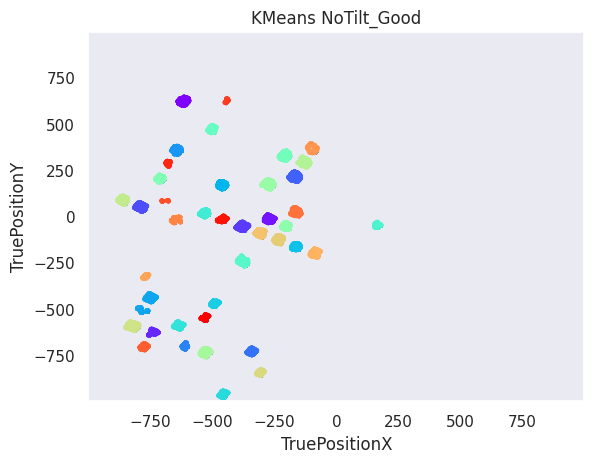

In [305]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset1 = 'No_Tilt_Good'

X = df_stats[df_stats['dataset'] == dataset1][x_axis]
y = df_stats[df_stats['dataset'] == dataset1][y_axis]

arr_X = X.to_numpy()
arr_y = y.to_numpy()

col_X_array = arr_X[:, np.newaxis]
col_y_array = arr_y[:, np.newaxis]

combined_array1 = np.concatenate((col_X_array, col_y_array), axis=1)

plt.scatter(X, y, alpha=1, label='No Tilt Good', s=1)

est1 = KMeans(41)  # Number of clusters
est1.fit(combined_array1)
est1.fit(combined_array1) #Trying doing this multiple times to optimize, I think it worked?
est1.fit(combined_array1)

y_kmeans1 = est1.predict(combined_array1)

plt.scatter(combined_array1[:, 0], combined_array1[:, 1], c=y_kmeans1, s=5, cmap='rainbow')
plt.title('KMeans NoTilt_Good')
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)

(-999.0, 999.0)

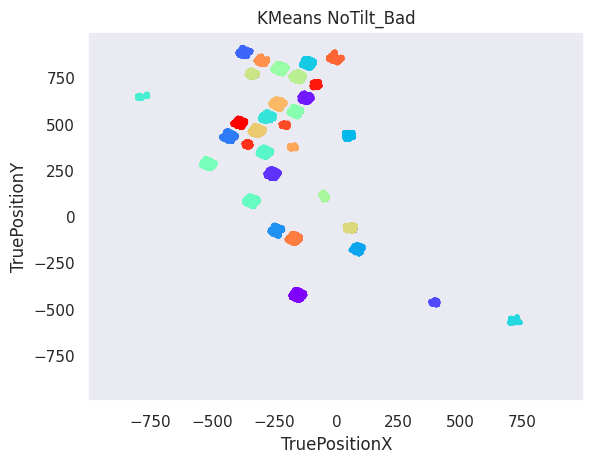

In [314]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset2 = 'No_Tilt_Bad'

X = df_stats[df_stats['dataset'] == dataset2][x_axis]
y = df_stats[df_stats['dataset'] == dataset2][y_axis]

arr_X = X.to_numpy()
arr_y = y.to_numpy()

col_X_array = arr_X[:, np.newaxis]
col_y_array = arr_y[:, np.newaxis]

combined_array2 = np.concatenate((col_X_array, col_y_array), axis=1)

plt.scatter(X, y, alpha=1, label='No Tilt Bad', s=1)

est2 = KMeans(32)  # Number of clusters
est2.fit(combined_array2)
est2.fit(combined_array2) #Trying doing this multiple times to optimize, I think it worked?
est2.fit(combined_array2)

y_kmeans2 = est2.predict(combined_array2)

plt.scatter(combined_array2[:, 0], combined_array2[:, 1], c=y_kmeans2, s=5, cmap='rainbow')
plt.title('KMeans NoTilt_Bad')
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)

(-999.0, 999.0)

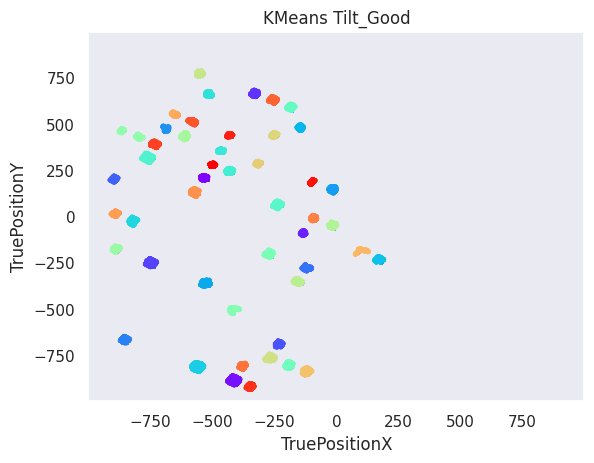

In [319]:
x_axis = 'TrueXPosition'
y_axis = 'TrueYPosition'
dataset3 = 'Tilt_Good'

X = df_stats[df_stats['dataset'] == dataset3][x_axis]
y = df_stats[df_stats['dataset'] == dataset3][y_axis]

arr_X = X.to_numpy()
arr_y = y.to_numpy()

col_X_array = arr_X[:, np.newaxis]
col_y_array = arr_y[:, np.newaxis]

combined_array3 = np.concatenate((col_X_array, col_y_array), axis=1)

plt.scatter(X, y, alpha=1, label='Tilt Good', s=1)

est3 = KMeans(48)  # Number of clusters
est3.fit(combined_array3)
est3.fit(combined_array3) #Trying doing this multiple times to optimize, I think it worked?
est3.fit(combined_array3)

y_kmeans3 = est3.predict(combined_array3)

plt.scatter(combined_array3[:, 0], combined_array3[:, 1], c=y_kmeans3, s=5, cmap='rainbow')
plt.title('KMeans Tilt_Good')
plt.xlabel('TruePositionX')
plt.ylabel('TruePositionY')
plt.grid(False)
plt.xlim(-999,999)
plt.ylim(-999,999)

In [375]:
labels_by_ds = {"No_Tilt_Good": y_kmeans1, "No_Tilt_Bad": y_kmeans2, "Tilt_Good": y_kmeans3}
centers_by_ds = {"No_Tilt_Good": combined_array1, "No_Tilt_Bad": combined_array2, "Tilt_Good": combined_array3}

In [376]:
# 1) Add kmeans_cluster to df, preserving original indices
cluster_col = pd.Series(index=df_stats.index, dtype="Int64")  # nullable int dtype

for ds, labels in labels_by_ds.items():
    idx = df_stats.index[df_stats["dataset"] == ds]  # indices of rows in this dataset
    if len(idx) != len(labels):
        raise ValueError(f"Length mismatch for dataset {ds}: df_stats has {len(idx)} rows, labels has {len(labels)}")
    cluster_col.loc[idx] = labels

df_stats = df_stats.assign(kmeans_cluster=cluster_col)

In [377]:
# 2) Build a table of centers keyed by (dataset, kmeans_cluster)
centers_parts = []
for ds, centers in centers_by_ds.items():
    centers = np.asarray(centers)
    centers_df = pd.DataFrame(
        centers,
        columns=["kmeans_X", "kmeans_Y"]
    )
    centers_df["dataset"] = ds
    centers_df["kmeans_cluster"] = centers_df.index  # assumes cluster labels are 0..k-1
    centers_parts.append(centers_df)

centers_all = pd.concat(centers_parts, ignore_index=True)

In [378]:
# 3) Merge centers onto df so each row gets its cluster center coords
df_stats = df_stats.merge(
    centers_all,
    on=["dataset", "kmeans_cluster"],
    how="left",
)

In [379]:
df_stats

,Index,Avg Inten.,DF Avg,Astig,CTF Fit,DF Range,Tilt Angle,Rel Ice Thick.,Motion dist.,Motion curv.,...,ImageShiftX,ImageShiftY,RotationAngle,FlashCounter,FEGCurrent,TrueXPosition,TrueYPosition,kmeans_cluster,kmeans_X,kmeans_Y
0,0,8.57,15949.768,141.38,3.855,1631,25.7,1.110,22.49,15.55,...,-0.337536,-0.171574,174.7,336,5.51,-251.370536,453.349426,32,-252.59188,451.93656
1,1,10.40,15941.739,158.65,4.036,1484,26.3,1.106,19.46,13.02,...,-0.271113,0.267517,174.7,336,5.51,-251.305113,453.788517,32,-252.59188,451.93656
2,2,7.79,16514.842,104.70,3.830,1815,26.8,1.106,24.90,15.94,...,0.169979,0.336909,174.7,336,5.51,-250.862021,453.857909,32,-252.59188,451.93656
3,3,8.52,16876.404,117.72,4.053,1396,25.0,1.109,24.66,15.15,...,0.376166,-0.059296,174.7,336,5.51,-250.655834,453.461704,32,-252.59188,451.93656
4,4,8.80,16596.109,35.02,3.702,1418,24.6,1.110,22.63,12.67,...,0.062504,-0.373555,174.7,336,5.51,-250.970496,453.147445,32,-252.59188,451.93656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78079,26023,9.71,9322.393,129.45,4.959,286,4.1,1.141,4.59,4.80,...,1.435360,-3.162900,174.7,349,6.15,-216.703640,307.330100,19,-816.53816,-601.80882
78080,26024,7.85,22871.205,77.61,5.058,400,4.1,1.135,5.50,5.23,...,-1.283750,2.983010,174.7,349,5.61,-271.338750,191.056010,22,-817.84201,-604.68173
78081,26025,8.41,8835.602,113.11,4.800,577,9.4,1.136,10.75,4.06,...,-2.574220,1.208600,174.7,349,6.15,-296.256220,177.470600,22,-817.84201,-604.68173
78082,26026,8.42,16754.408,101.68,4.152,387,5.2,1.121,5.11,4.85,...,3.299130,1.449910,174.7,349,5.71,-273.038870,194.060910,22,-817.84201,-604.68173


In [380]:
import math

df_stats['DistanceFromSquareCenter_X']=df_stats['TrueXPosition'] - df_stats['kmeans_X']
df_stats['DistanceFromSquareCenter_Y']=df_stats['TrueYPosition'] - df_stats['kmeans_Y']

df_stats

,Index,Avg Inten.,DF Avg,Astig,CTF Fit,DF Range,Tilt Angle,Rel Ice Thick.,Motion dist.,Motion curv.,...,RotationAngle,FlashCounter,FEGCurrent,TrueXPosition,TrueYPosition,kmeans_cluster,kmeans_X,kmeans_Y,DistanceFromSquareCenter_X,DistanceFromSquareCenter_Y
0,0,8.57,15949.768,141.38,3.855,1631,25.7,1.110,22.49,15.55,...,174.7,336,5.51,-251.370536,453.349426,32,-252.59188,451.93656,1.221344,1.412866
1,1,10.40,15941.739,158.65,4.036,1484,26.3,1.106,19.46,13.02,...,174.7,336,5.51,-251.305113,453.788517,32,-252.59188,451.93656,1.286767,1.851957
2,2,7.79,16514.842,104.70,3.830,1815,26.8,1.106,24.90,15.94,...,174.7,336,5.51,-250.862021,453.857909,32,-252.59188,451.93656,1.729859,1.921349
3,3,8.52,16876.404,117.72,4.053,1396,25.0,1.109,24.66,15.15,...,174.7,336,5.51,-250.655834,453.461704,32,-252.59188,451.93656,1.936046,1.525144
4,4,8.80,16596.109,35.02,3.702,1418,24.6,1.110,22.63,12.67,...,174.7,336,5.51,-250.970496,453.147445,32,-252.59188,451.93656,1.621384,1.210885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78079,26023,9.71,9322.393,129.45,4.959,286,4.1,1.141,4.59,4.80,...,174.7,349,6.15,-216.703640,307.330100,19,-816.53816,-601.80882,599.834520,909.138920
78080,26024,7.85,22871.205,77.61,5.058,400,4.1,1.135,5.50,5.23,...,174.7,349,5.61,-271.338750,191.056010,22,-817.84201,-604.68173,546.503260,795.737740
78081,26025,8.41,8835.602,113.11,4.800,577,9.4,1.136,10.75,4.06,...,174.7,349,6.15,-296.256220,177.470600,22,-817.84201,-604.68173,521.585790,782.152330
78082,26026,8.42,16754.408,101.68,4.152,387,5.2,1.121,5.11,4.85,...,174.7,349,5.71,-273.038870,194.060910,22,-817.84201,-604.68173,544.803140,798.742640


In [381]:
df_stats["DistanceFromSquareCenter_Y"].dtypes

dtype('float64')

In [383]:
df_stats["LinearDistanceFromSquareCenter"] = np.sqrt(
    df_stats["DistanceFromSquareCenter_X"]**2 +
    df_stats["DistanceFromSquareCenter_Y"]**2
)

In [384]:
df_stats

,Index,Avg Inten.,DF Avg,Astig,CTF Fit,DF Range,Tilt Angle,Rel Ice Thick.,Motion dist.,Motion curv.,...,FlashCounter,FEGCurrent,TrueXPosition,TrueYPosition,kmeans_cluster,kmeans_X,kmeans_Y,DistanceFromSquareCenter_X,DistanceFromSquareCenter_Y,LinearDistanceFromSquareCenter
0,0,8.57,15949.768,141.38,3.855,1631,25.7,1.110,22.49,15.55,...,336,5.51,-251.370536,453.349426,32,-252.59188,451.93656,1.221344,1.412866,1.867584
1,1,10.40,15941.739,158.65,4.036,1484,26.3,1.106,19.46,13.02,...,336,5.51,-251.305113,453.788517,32,-252.59188,451.93656,1.286767,1.851957,2.255108
2,2,7.79,16514.842,104.70,3.830,1815,26.8,1.106,24.90,15.94,...,336,5.51,-250.862021,453.857909,32,-252.59188,451.93656,1.729859,1.921349,2.585342
3,3,8.52,16876.404,117.72,4.053,1396,25.0,1.109,24.66,15.15,...,336,5.51,-250.655834,453.461704,32,-252.59188,451.93656,1.936046,1.525144,2.464617
4,4,8.80,16596.109,35.02,3.702,1418,24.6,1.110,22.63,12.67,...,336,5.51,-250.970496,453.147445,32,-252.59188,451.93656,1.621384,1.210885,2.023643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78079,26023,9.71,9322.393,129.45,4.959,286,4.1,1.141,4.59,4.80,...,349,6.15,-216.703640,307.330100,19,-816.53816,-601.80882,599.834520,909.138920,1089.190079
78080,26024,7.85,22871.205,77.61,5.058,400,4.1,1.135,5.50,5.23,...,349,5.61,-271.338750,191.056010,22,-817.84201,-604.68173,546.503260,795.737740,965.331220
78081,26025,8.41,8835.602,113.11,4.800,577,9.4,1.136,10.75,4.06,...,349,6.15,-296.256220,177.470600,22,-817.84201,-604.68173,521.585790,782.152330,940.113825
78082,26026,8.42,16754.408,101.68,4.152,387,5.2,1.121,5.11,4.85,...,349,5.71,-273.038870,194.060910,22,-817.84201,-604.68173,544.803140,798.742640,966.850695
